In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Smart Agriculture-data_season.csv")
df.describe()

,Year,Area,Rainfall,Temperature,yeilds,Humidity,price
count,3158.000000,3158.000000,3158.000000,3158.000000,3158.000000,3158.000000,3158.000000
mean,2009.929702,9329.913553,2813.126662,65.893699,23258.976916,55.582331,86271.279291
std,5.100895,15180.465396,1163.829953,60.814037,58228.985033,2.469773,94123.160706
min,2004.000000,1.000000,233.000000,26.800000,2.000000,50.000000,637.000000
25%,2004.000000,153.000000,2903.100000,27.000000,393.000000,54.000000,2644.000000
50%,2010.000000,2127.000000,3296.000000,38.000000,2783.000000,56.000000,45186.000000
75%,2015.000000,10910.000000,3550.000000,43.000000,6589.000000,57.000000,203317.000000
max,2019.000000,52119.000000,3729.800000,222.000000,623687.000000,60.000000,249978.000000


In [ ]:
import pandas as pd

In [ ]:
df.shape

(3158, 12)

In [ ]:
df.columns

Index(['Year', 'Location', 'Area', 'Rainfall', 'Temperature', 'Soil type',
       'Irrigation', 'yeilds', 'Humidity', 'Crops', 'price', 'Season'],
      dtype='object')

In [ ]:
df.dtypes

Year             int64
Location        object
Area             int64
Rainfall       float64
Temperature    float64
Soil type       object
Irrigation      object
yeilds         float64
Humidity       float64
Crops           object
price            int64
Season          object
dtype: object

In [ ]:
df.head()

,Year,Location,Area,Rainfall,Temperature,Soil type,Irrigation,yeilds,Humidity,Crops,price,Season
0,2004,Mangalore,1279,2903.1,27.0,Alluvial,Drip,2570.0,57.0,Coconut,200000,Kharif
1,2004,Mangalore,13283,2903.1,27.0,Alluvial,Drip,27170.0,57.5,Coconut,4847,Kharif
2,2004,Mangalore,52119,2903.1,27.0,Alluvial,Drip,114744.0,57.0,Coconut,51239,Kharif
3,2004,Mangalore,725,2996.6,27.0,Alluvial,Drip,1402.0,55.0,Coconut,216396,Kharif
4,2004,Mangalore,12885,2996.6,27.0,Alluvial,Drip,23456.0,56.0,Coconut,2644,Kharif


In [ ]:
df.tail()

,Year,Location,Area,Rainfall,Temperature,Soil type,Irrigation,yeilds,Humidity,Crops,price,Season
3153,2013,Davangere,46990,3296.0,27.0,NaN,Drip,107809.0,53.5,Coconut,51239,Rabi
3154,2014,Davangere,103,3296.0,27.0,NaN,Drip,1132.0,52.5,Coconut,216396,Rabi
3155,2015,Davangere,8239,3550.0,27.0,NaN,Drip,23960.0,56.0,Coconut,2644,Rabi
3156,2016,Davangere,44563,3550.0,27.0,NaN,Drip,126487.0,57.0,Coconut,44235,Rabi
3157,2017,Davangere,96,3550.0,27.0,NaN,Drip,804.0,57.5,Coconut,203317,Rabi


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         3158 non-null   int64  
 1   Location     3158 non-null   object 
 2   Area         3158 non-null   int64  
 3   Rainfall     3158 non-null   float64
 4   Temperature  3158 non-null   float64
 5   Soil type    3100 non-null   object 
 6   Irrigation   3158 non-null   object 
 7   yeilds       3158 non-null   float64
 8   Humidity     3158 non-null   float64
 9   Crops        3158 non-null   object 
 10  price        3158 non-null   int64  
 11  Season       3158 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 296.2+ KB


In [ ]:
df.isnull().sum()

Year            0
Location        0
Area            0
Rainfall        0
Temperature     0
Soil type      58
Irrigation      0
yeilds          0
Humidity        0
Crops           0
price           0
Season          0
dtype: int64

In [ ]:
df=df.drop_duplicates()
print("\nAfter Removing Duplicates:",df.shape)


After Removing Duplicates: (3158, 12)


In [ ]:
#if target column is text(example:Crope),encode it
if 'Crops' in df.columns:
    from sklearn.preprocessing import LabelEncoder
    le=LabelEncoder()
    df['Crops'] = le.fit_transform(df['Crops'])
    print("\nCrops column encoded successfully!")


Crops column encoded successfully!


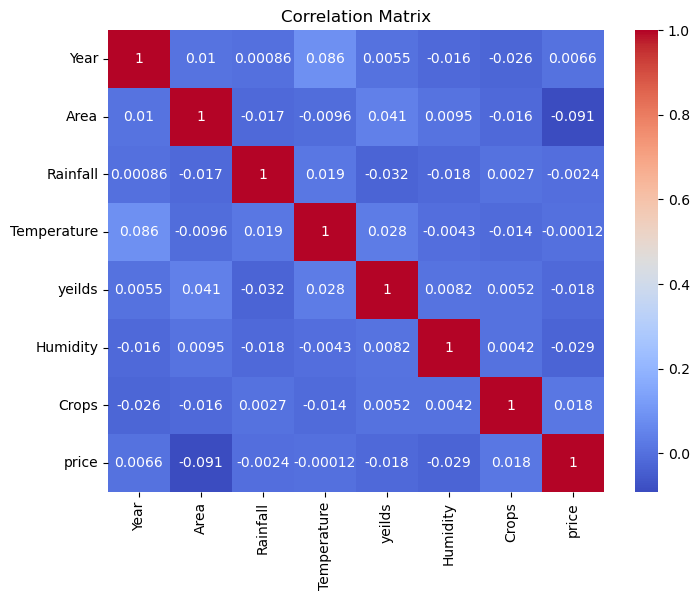

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

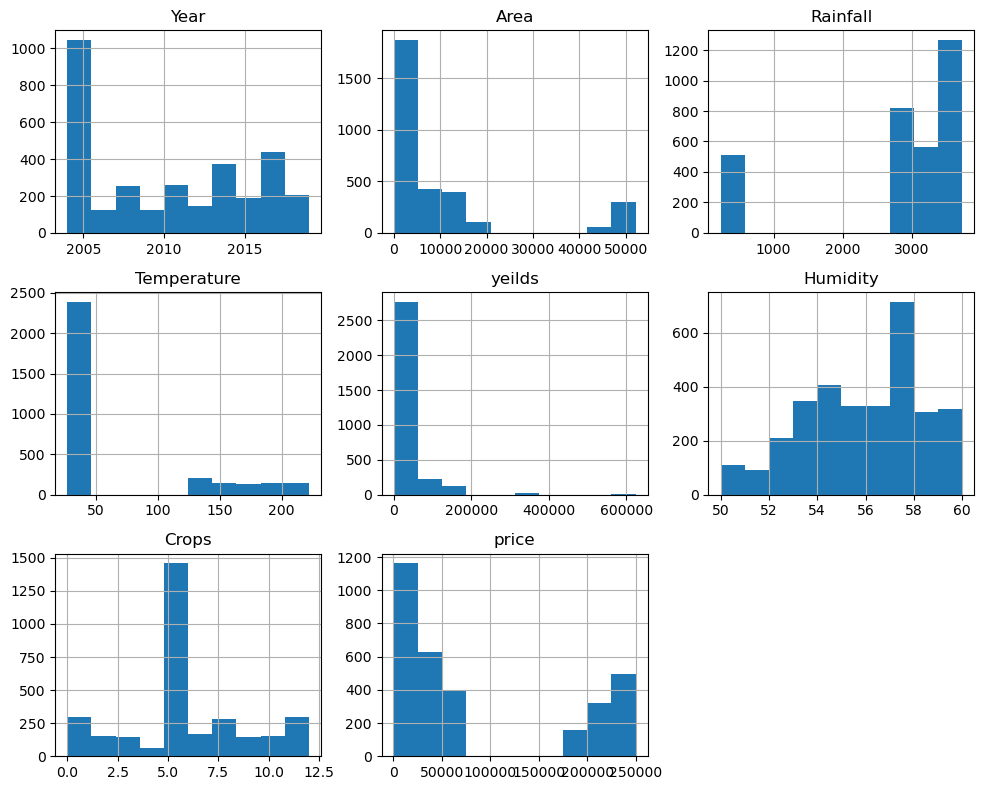

In [ ]:
#Histogram for all numeric columns
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

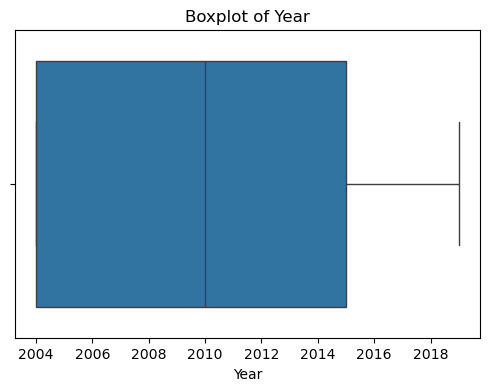

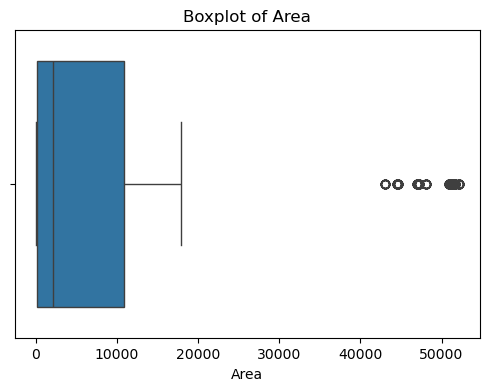

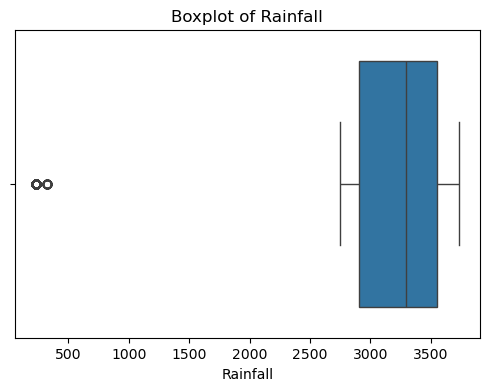

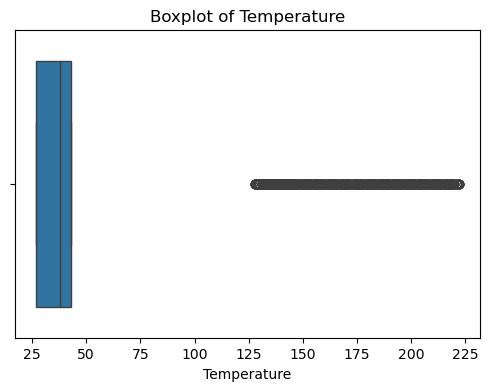

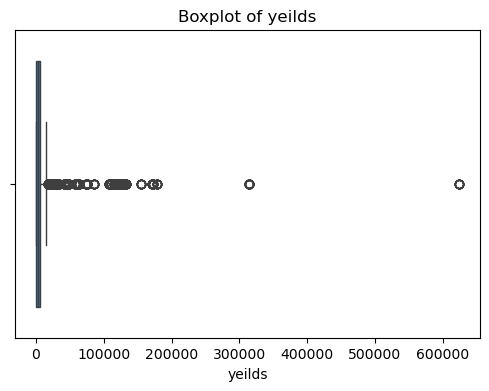

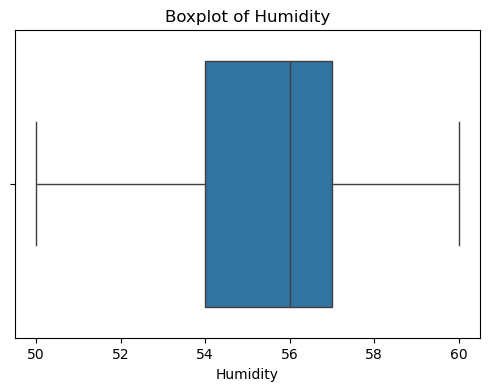

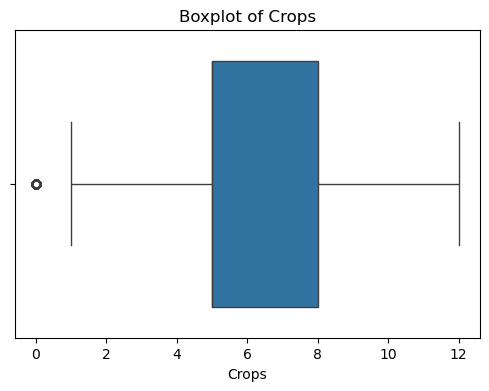

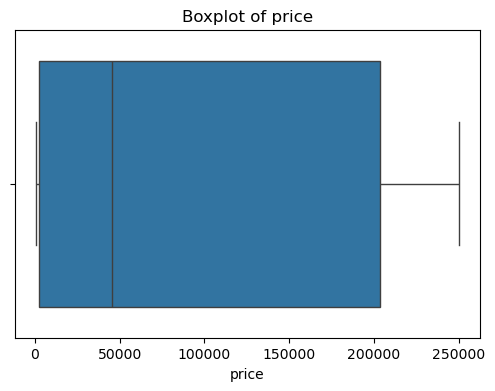

In [ ]:
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:

# SMART AGRICULTURE - CROP PREDICTION MODEL

# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# STEP 2: Load Dataset
df = pd.read_csv("Smart Agriculture-data_season.csv")


# STEP 3: Handle Categorical Columns (Encoding)
label_cols = ["Location", "Soil type", "Irrigation", "Season", "Crops"]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])


# STEP 4: Define Features (X) and Target (y)
X = df.drop("Crops", axis=1)
y = df["Crops"]


# STEP 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# STEP 6: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# STEP 7: Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# STEP 8: Prediction
y_pred = model.predict(X_test)


# STEP 9: Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# STEP 10: Save Model
joblib.dump(model, "smart_agriculture_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Accuracy: 0.870253164556962

Confusion Matrix:
 [[ 27   0   0   0   0   3   0   0   2   0   0   0   0]
 [  0  24   0   1   0   6   0   0   0   0   0   0   0]
 [  0   0  23   1   0   5   1   0   0   0   0   2   0]
 [  0   0   0  24   0   4   0   1   0   0   0   0   0]
 [  0   0   1   0   9   1   7   0   0   0   0   0   0]
 [  0   0   0   3   0 286   0   0   0   0   0   1   0]
 [  0   0   2   2   0   6  28   0   0   0   0   1   0]
 [  0   0   0   0   0   1   0   3   0   2   0   1   0]
 [  0   0   0   0   0   5   0   0  41   0   0   0   0]
 [  0   0   0   0   0   1   0   0   0  23   0   0   0]
 [  0   0   0   0   0   1   0   0   0   1  21   0   0]
 [  3   0   1   1   0   4   1   0   0   0   0  19   0]
 [  1   0   0   0   0   2   0   0   2   0   5   0  22]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.86        32
           1       1.00      0.77      0.87        31
           2       0.85      0.72      0.78     

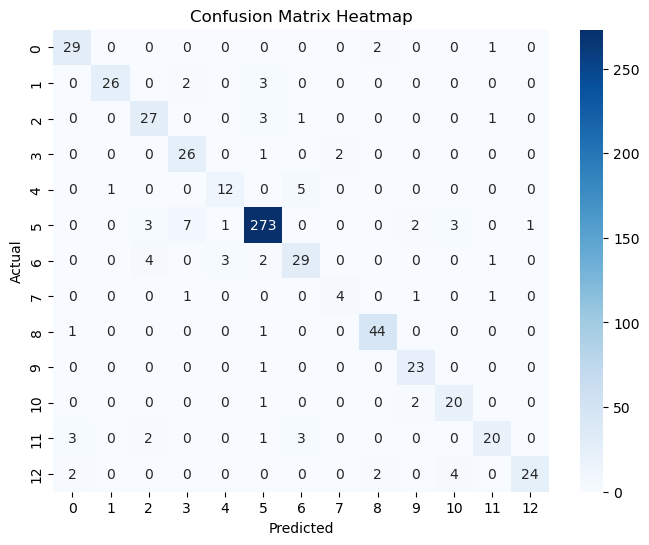


Feature Importance:
         Feature  Importance
6    Irrigation    0.143866
4   Temperature    0.126888
5     Soil type    0.119667
7        yeilds    0.106562
1      Location    0.105027
2          Area    0.079172
0          Year    0.069145
3      Rainfall    0.068304
8      Humidity    0.067110
10       Season    0.063961
9         price    0.050299

Model Saved Successfully!


In [ ]:


# 1️.Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#  Feature Importance
importance = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", importance_df)


# 1
# 
# 
# 
# Save Model
joblib.dump(model, "smart_agriculture_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel Saved Successfully!")